In [16]:
import numpy as np
import pandas as pd

In [17]:
# DATA LOAD
# excel file load
df = pd.read_excel(r"D:\sales_data.xlsx")


In [18]:
# first 5 rows
print(df.head())

   U.NO COMPANY NAME PRODUCT NAME   QUANTITY  PURCHASE PRICE  SELL PRICE  \
0   1.0       Jaipan         Mixer         1            1900        2700   
1   1.0  Bajaj Mixer         Mixer         1            2200        2600   
2   2.0       Seemar        Cooker         1             500         600   
3   3.0       Indane         Batla         1             440         490   
4   3.0       Indane         Batla         1             440         520   

  PRODUCT OWNER       Date  
0    vinod bhai 2025-08-01  
1    tripati ji 2025-08-01  
2   deepak bhai 2025-08-01  
3          khan 2025-08-01  
4          khan 2025-08-01  


In [19]:
# last 5 rows
print(df.tail())
# columns check
print(df.columns)
# df info
df.info()
# df describe
df.describe()
# SHAPE
df.shape


      U.NO     COMPANY NAME PRODUCT NAME   QUANTITY  PURCHASE PRICE  \
1023   3.0           Indane         Batla         1             450   
1024   2.0           Seemar        Cooker         1             530   
1025   2.0           litchi        Cooker         1             840   
1026   4.0        surya gas     Gas Stove         1             620   
1027   7.0  Bharat GAS pipe      Gas pipe         1              75   

      SELL PRICE     PRODUCT OWNER       Date  
1023         500              khan 2026-02-10  
1024         680       Deepak bhai 2026-02-10  
1025        1200             ramji 2026-02-10  
1026         780  Laxmi enterprice 2026-02-10  
1027          90  Laxmi enterprice 2026-02-10  
Index(['U.NO', 'COMPANY NAME', 'PRODUCT NAME ', 'QUANTITY', 'PURCHASE PRICE',
       'SELL PRICE', 'PRODUCT OWNER', 'Date'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1028 entries, 0 to 1027
Data columns (total 8 columns):
 #   Column          Non-Null Co

(1028, 8)

In [20]:

#MISSING VALUES CHECK
df.isnull().sum()

U.NO              1
COMPANY NAME      0
PRODUCT NAME      0
QUANTITY          0
PURCHASE PRICE    0
SELL PRICE        0
PRODUCT OWNER     0
Date              0
dtype: int64

In [21]:
# drop missing values
df.dropna(inplace=True)
df.isnull().sum()


U.NO              0
COMPANY NAME      0
PRODUCT NAME      0
QUANTITY          0
PURCHASE PRICE    0
SELL PRICE        0
PRODUCT OWNER     0
Date              0
dtype: int64

In [22]:
# REMOVE DUPLICATES VALUES
df.drop_duplicates(inplace=True)

In [23]:
df[df.duplicated()]

,U.NO,COMPANY NAME,PRODUCT NAME,QUANTITY,PURCHASE PRICE,SELL PRICE,PRODUCT OWNER,Date


In [24]:
# CREATE PROFIT COLUMN
df["Total Profit"] = (df["SELL PRICE"] - df["PURCHASE PRICE"])

In [25]:
df

,U.NO,COMPANY NAME,PRODUCT NAME,QUANTITY,PURCHASE PRICE,SELL PRICE,PRODUCT OWNER,Date,Total Profit
0,1.0,Jaipan,Mixer,1,1900,2700,vinod bhai,2025-08-01,800
1,1.0,Bajaj Mixer,Mixer,1,2200,2600,tripati ji,2025-08-01,400
2,2.0,Seemar,Cooker,1,500,600,deepak bhai,2025-08-01,100
3,3.0,Indane,Batla,1,440,490,khan,2025-08-01,50
4,3.0,Indane,Batla,1,440,520,khan,2025-08-01,80
...,...,...,...,...,...,...,...,...,...
1023,3.0,Indane,Batla,1,450,500,khan,2026-02-10,50
1024,2.0,Seemar,Cooker,1,530,680,Deepak bhai,2026-02-10,150
1025,2.0,litchi,Cooker,1,840,1200,ramji,2026-02-10,360
1026,4.0,surya gas,Gas Stove,1,620,780,Laxmi enterprice,2026-02-10,160


In [26]:
df["Total Profit"].dtype

dtype('int64')

In [27]:
df["PRODUCT NAME"] = df["PRODUCT NAME"].str.strip()

KeyError: 'PRODUCT NAME'

In [ ]:
df["PRODUCT NAME"] = df["PRODUCT NAME"].str.title()

In [ ]:
df["COMPANY NAME"] = df["COMPANY NAME"].str.strip().str.title()

In [ ]:
df["PRODUCT OWNER"] = df["PRODUCT OWNER"].str.strip().str.title()


In [ ]:
df["PRODUCT OWNER"] = df["PRODUCT OWNER"].str.replace(r"\s+"," ", regex=True).str.strip().str.title()

* DATA ANALYSIS

In [ ]:
# TOTAL SALES
total_sales = df["SELL PRICE"].sum()
print("Total Sales:", total_sales)

In [ ]:
# Top Selling Product
df.groupby("PRODUCT NAME")["QUANTITY"].sum().sort_values(ascending=False)

In [ ]:
# Company Wise Sales-profit
df.groupby("COMPANY NAME")[["SELL PRICE","Total Profit"]].sum().sort_values(by="Total Profit",ascending=False)

In [ ]:
#Owner Wise Sales
data_analsis = df.groupby("PRODUCT OWNER")["SELL PRICE"].sum().sort_values(ascending=False)
print(data_analsis)

In [ ]:
df['PRODUCT OWNER'] = df['PRODUCT OWNER'].replace({
    'Himalya': 'Himalya Gold'
})


In [ ]:
df['PRODUCT OWNER'] = df['PRODUCT OWNER'].replace({
    'Dipa Traders': 'Neepa Traders'
})

In [ ]:
# Analyze which company brands are supplied by each product owner
Owner_Brands = df.groupby("PRODUCT OWNER")["COMPANY NAME"].unique().apply(list)
print(Owner_Brands)

In [ ]:
#create month column
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.strftime("%B%Y")

In [ ]:
#month wise sales
monthly_sales = df.groupby("Month")["SELL PRICE"].sum().reset_index()
print(monthly_sales)

In [ ]:
# Unwanted months list
remove_months = ["October1900", "March2025", "September2026"]

# Keep only rows not in remove_months
df = df[~df['Month'].isin(remove_months)]


* DATA VISUALIZATION

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns


* TOTAL SALES(KPI) VISUALZATION = (MATPLOTLIB)

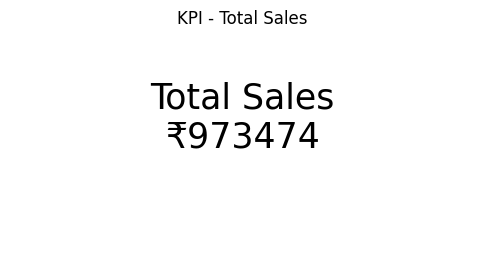

In [29]:
import matplotlib.pyplot as plt

total_sales = df["SELL PRICE"].sum()

plt.figure(figsize=(6,3))

plt.text(0.5,0.5,f"Total Sales\n₹{total_sales}",
         fontsize=25,
         ha='center')

plt.axis('off')

plt.title("KPI - Total Sales")

plt.show()

* Company Wise Sales-profit

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top products calculate
top_products = df.groupby("PRODUCT NAME")["QUANTITY"].sum().sort_values(ascending=False)

# graph
plt.figure(figsize=(10,5))

sns.barplot(x=top_products.index, y=top_products.values)

plt.title("Top Selling Products")
plt.xlabel("Product Name")
plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=45)

plt.show()

KeyError: 'PRODUCT NAME'

* Company Wise Sales vs Profit Graph

In [ ]:
company_sales_profit = df.groupby("COMPANY NAME")[["SELL PRICE","Total Profit"]]\
.sum().sort_values(by="Total Profit", ascending=False).head(10)

company_sales_profit.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Companies by Profit")
plt.xlabel("Company Name")
plt.ylabel("Amount")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Owner wise 
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x=data_analsis.values, y=data_analsis.index)

plt.title("Owner Wise Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Owner")

plt.show()

In [ ]:
!pip install networkx

In [ ]:
# Count number of brands per owner
brand_counts = Owner_Brands.apply(len)

# Get top 5 owners
top5_owners = brand_counts.sort_values(ascending=False).head(5).index

# Filter Owner_Brands to only top 5
top5_owner_brands = Owner_Brands.loc[top5_owners]

In [ ]:
# Analyze which company brands are supplied by each product owner
import networkx as nx
import matplotlib.pyplot as plt

# Top 5 owners by number of brands
brand_counts = Owner_Brands.apply(len)
top5_owners = brand_counts.sort_values(ascending=False).head(5).index
top5_owner_brands = Owner_Brands.loc[top5_owners]

# Build graph
G = nx.Graph()
for owner, brands in top5_owner_brands.items():
    for brand in brands:
        G.add_edge(owner, brand)

# Set node colors
node_colors = []
for node in G.nodes():
    if node in top5_owner_brands.index:   # owner
        node_colors.append("orange")
    else:                                 # brand
        node_colors.append("lightblue")

# Draw graph
plt.figure(figsize=(12,6))
nx.draw(G, with_labels=True, node_color=node_colors, node_size=1500, font_size=10)
plt.title("Top 5 Product Owners and Their Brands")
plt.show()

In [ ]:


# Step 1: Create Month column from Date
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period('M')  # This ensures proper chronological order

# Step 2: Month-wise sales
monthly_sales = df.groupby("Month")["SELL PRICE"].sum().reset_index()
monthly_sales['Month_dt'] = monthly_sales['Month'].dt.to_timestamp()  # Convert to datetime for plotting

# Step 3: Simple line chart
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month_dt'], monthly_sales['SELL PRICE'], marker='o', color='blue', linewidth=2)

# Formatting x-axis
plt.xticks(monthly_sales['Month_dt'], monthly_sales['Month_dt'].dt.strftime('%b %Y'), rotation=45)
plt.xlabel("Month")
plt.ylabel("Total Sell Price")
plt.title("Month-wise Sales")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# daily revenue load excel file

In [34]:
df1 = pd.read_excel(r"D:\PEM1.xlsx")

C:\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
C:\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [35]:
df1

,Date,DAY,Cash Revenue,Online Transaction,Total Revenue,PROFIT,PROFIT%,MONTH,YEAR
0,2025-07-01,Tuesday,4545.0,1980.0,6525,1440.0,22.068966,July 2025,2025
1,2025-07-02,Wednesday,2580.0,2439.0,5019,1540.0,30.683403,July 2025,2025
2,2025-07-03,Thursday,6160.0,1970.0,8130,1750.0,21.525215,July 2025,2025
3,2025-07-04,Friday,4220.0,1640.0,5860,1650.0,28.156997,July 2025,2025
4,2025-07-05,Saturday,930.0,4210.0,5140,1450.0,28.210117,July 2025,2025
...,...,...,...,...,...,...,...,...,...
245,2026-03-09,Monday,NaN,NaN,0,NaN,NaN,March 2026,2026
246,2026-03-10,Tuesday,NaN,NaN,0,NaN,NaN,March 2026,2026
247,2026-03-11,Wednesday,NaN,NaN,0,NaN,NaN,March 2026,2026
248,2026-03-12,Thursday,NaN,NaN,0,NaN,NaN,March 2026,2026


In [36]:
df1.head()

,Date,DAY,Cash Revenue,Online Transaction,Total Revenue,PROFIT,PROFIT%,MONTH,YEAR
0,2025-07-01,Tuesday,4545.0,1980.0,6525,1440.0,22.068966,July 2025,2025
1,2025-07-02,Wednesday,2580.0,2439.0,5019,1540.0,30.683403,July 2025,2025
2,2025-07-03,Thursday,6160.0,1970.0,8130,1750.0,21.525215,July 2025,2025
3,2025-07-04,Friday,4220.0,1640.0,5860,1650.0,28.156997,July 2025,2025
4,2025-07-05,Saturday,930.0,4210.0,5140,1450.0,28.210117,July 2025,2025


In [37]:
df1.tail()

,Date,DAY,Cash Revenue,Online Transaction,Total Revenue,PROFIT,PROFIT%,MONTH,YEAR
245,2026-03-09,Monday,NaN,NaN,0,NaN,NaN,March 2026,2026
246,2026-03-10,Tuesday,NaN,NaN,0,NaN,NaN,March 2026,2026
247,2026-03-11,Wednesday,NaN,NaN,0,NaN,NaN,March 2026,2026
248,2026-03-12,Thursday,NaN,NaN,0,NaN,NaN,March 2026,2026
249,2026-03-13,Friday,NaN,NaN,0,NaN,NaN,March 2026,2026


In [38]:
df1.shape

(250, 9)

In [39]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                250 non-null    datetime64[ns]
 1   DAY                 250 non-null    object        
 2   Cash Revenue        245 non-null    float64       
 3   Online Transaction  245 non-null    float64       
 4   Total Revenue       250 non-null    int64         
 5   PROFIT              245 non-null    float64       
 6   PROFIT%             245 non-null    float64       
 7   MONTH               250 non-null    object        
 8   YEAR                250 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 17.7+ KB


In [40]:
df1.describe()

,Date,Cash Revenue,Online Transaction,Total Revenue,PROFIT,PROFIT%,YEAR
count,250,245.000000,245.000000,250.000000,245.000000,245.000000,250.0000
mean,2025-11-04 20:09:36,6813.995918,8017.734694,14535.096000,3544.771429,25.016567,2025.2800
min,2025-07-01 00:00:00,910.000000,650.000000,0.000000,800.000000,7.713755,2025.0000
25%,2025-09-02 06:00:00,4270.000000,4365.000000,9231.250000,2400.000000,21.698787,2025.0000
50%,2025-11-04 12:00:00,5830.000000,6540.000000,13080.000000,3150.000000,24.517315,2025.0000
75%,2026-01-07 18:00:00,8460.000000,9825.000000,17035.000000,4100.000000,27.737226,2026.0000
max,2026-03-13 00:00:00,31100.000000,65550.000000,83590.000000,17130.000000,64.775252,2026.0000
std,NaN,3965.284089,6893.558374,8959.383958,1824.250445,5.855162,0.4499


In [41]:
df.columns

Index(['U.NO', 'COMPANY NAME', 'PRODUCT NAME ', 'QUANTITY', 'PURCHASE PRICE',
       'SELL PRICE', 'PRODUCT OWNER', 'Date', 'Total Profit'],
      dtype='object')

In [42]:
df1.columns = df1.columns.str.strip().str.title()

In [43]:
df1.columns

Index(['Date', 'Day', 'Cash Revenue', 'Online Transaction', 'Total Revenue',
       'Profit', 'Profit%', 'Month', 'Year'],
      dtype='object')

In [44]:
df1.dropna(inplace=True)

In [45]:
df1.tail()

,Date,Day,Cash Revenue,Online Transaction,Total Revenue,Profit,Profit%,Month,Year
240,2026-03-04,Wednesday,4225.0,5825.0,10050,2400.0,23.880597,March 2026,2026
241,2026-03-05,Thursday,9500.0,3900.0,13400,3000.0,22.388060,March 2026,2026
242,2026-03-06,Friday,5900.0,6955.0,12855,3000.0,23.337223,March 2026,2026
243,2026-03-07,Saturday,7955.0,13320.0,21275,4570.0,21.480611,March 2026,2026
244,2026-03-08,Sunday,11790.0,17950.0,29740,7710.0,25.924681,March 2026,2026


In [46]:

# Ensure Date column is datetime
df1['Date'] = pd.to_datetime(df1['Date'])

# Create Month column in datetime format for proper sorting
df1['Month_dt'] = df1['Date'].dt.to_period('M').dt.to_timestamp()

In [47]:
monthwise_sales = df1.groupby('Month_dt')['Total Revenue'].sum().reset_index()

# Month-wise Revenue Trend

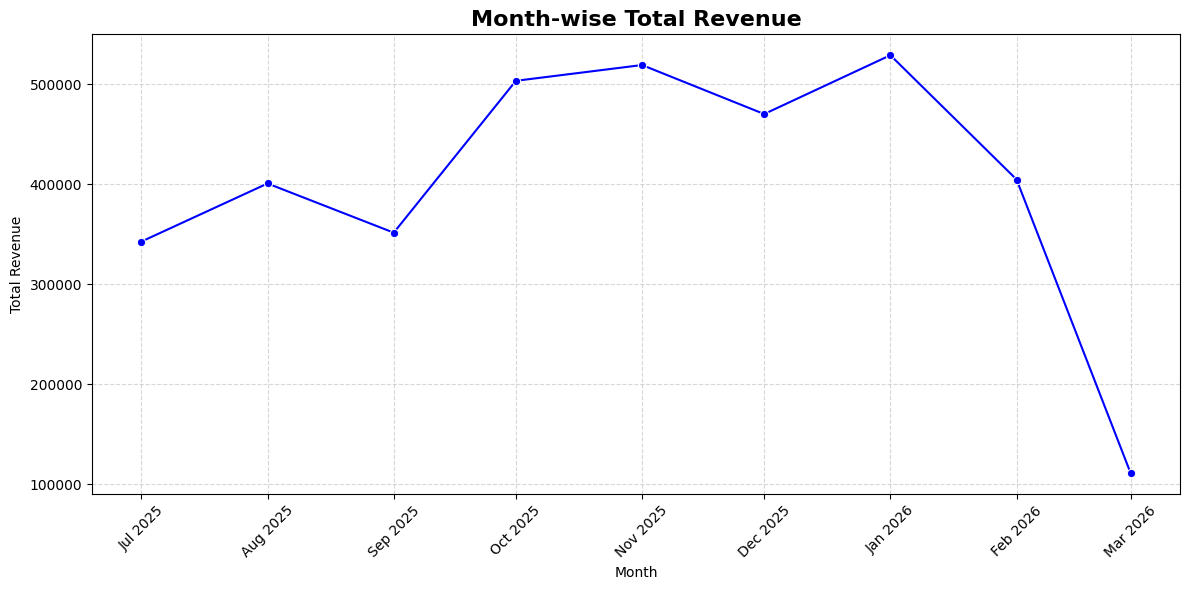

In [48]:
plt.figure(figsize=(12,6))
sns.lineplot(data=monthwise_sales, x='Month_dt', y='Total Revenue', marker='o', color='blue')
plt.title("Month-wise Total Revenue", fontsize=16, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(monthwise_sales['Month_dt'], monthwise_sales['Month_dt'].dt.strftime('%b %Y'), rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Date wise Revenue

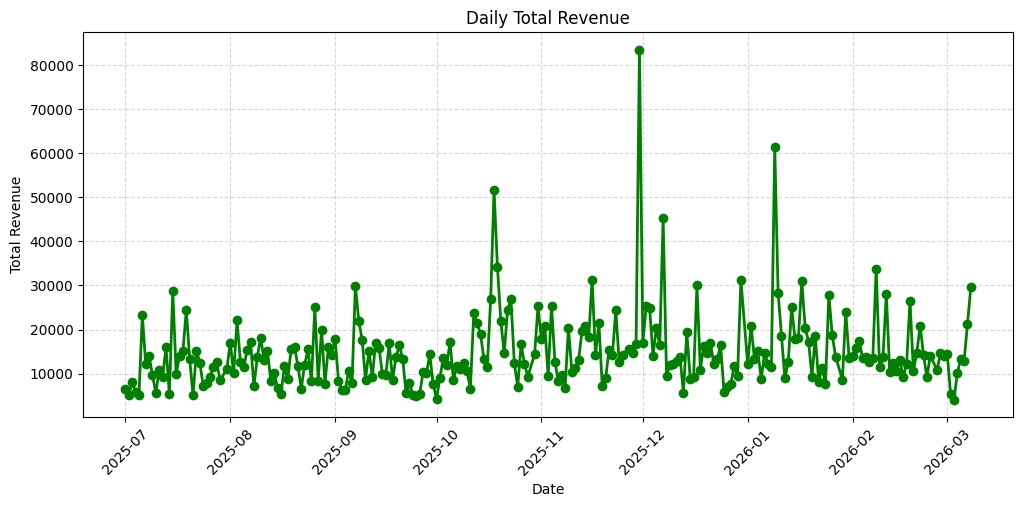

In [49]:
plt.figure(figsize=(12,5))
plt.plot(df1['Date'], df1['Total Revenue'], marker='o', color='green', linewidth=2)
plt.title("Daily Total Revenue")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

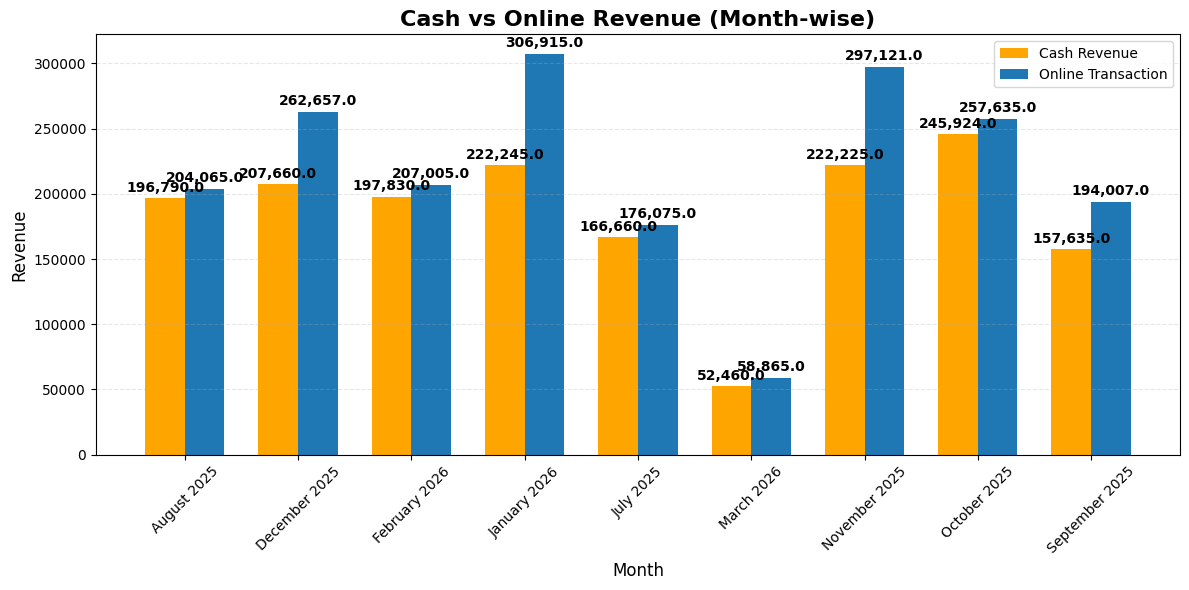

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
monthly_source = df1.groupby("Month")[['Cash Revenue','Online Transaction']].sum()
months = monthly_source.index
cash = monthly_source['Cash Revenue'].values
online = monthly_source['Online Transaction'].values

# Bar width and positions
bar_width = 0.35
r1 = np.arange(len(months))
r2 = [x + bar_width for x in r1]

# Plot
plt.figure(figsize=(12,6))
plt.bar(r1, cash, width=bar_width, color='#FFA500', label='Cash Revenue')
plt.bar(r2, online, width=bar_width, color='#1f77b4', label='Online Transaction')

# Labels
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.title("Cash vs Online Revenue (Month-wise)", fontsize=16, fontweight='bold')
plt.xticks([r + bar_width/2 for r in range(len(months))], months, rotation=45)
plt.legend()

# Add value labels on top of bars
for i in range(len(cash)):
    plt.text(r1[i], cash[i] + max(cash)*0.01, f'{cash[i]:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.text(r2[i], online[i] + max(online)*0.01, f'{online[i]:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# profit percentage

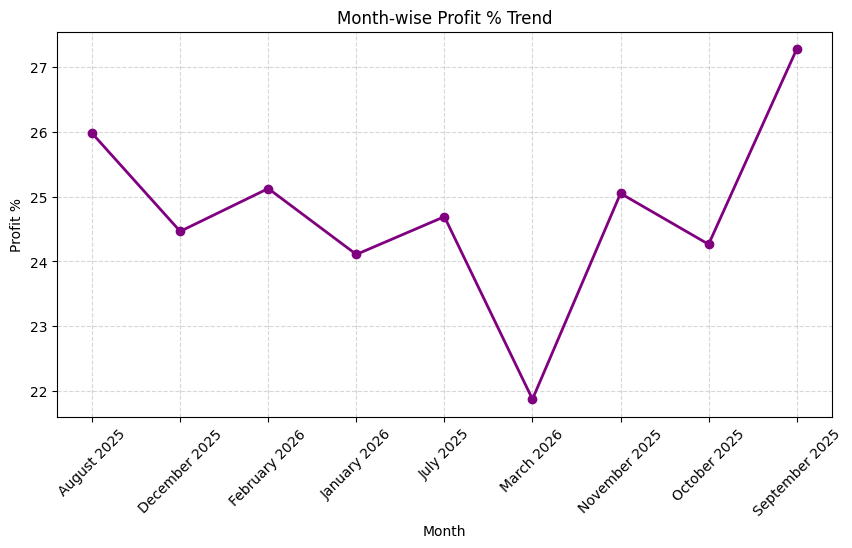

In [51]:
monthly_profit = df1.groupby("Month")["Profit%"].mean().reset_index()
plt.figure(figsize=(10,5))
plt.plot(monthly_profit['Month'], monthly_profit['Profit%'], marker='o', color='purple', linewidth=2)
plt.title("Month-wise Profit % Trend")
plt.ylabel("Profit %")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

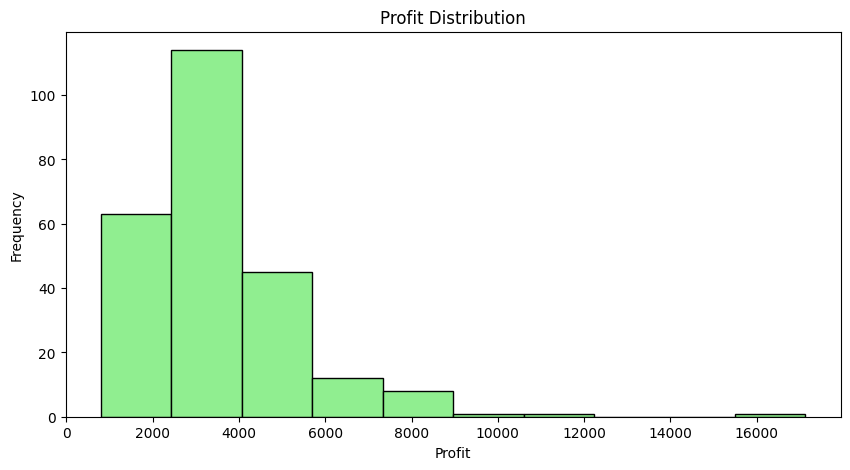

In [52]:
# profit distribution
plt.figure(figsize=(10,5))
plt.hist(df1['Profit'], bins=10, color='lightgreen', edgecolor='black')
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

# Total Revenue vs Profit scatter plot

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df1['Total Revenue'], df1['Profit'], color='red')
plt.title("Total Revenue vs Profit")
plt.xlabel("Total Revenue")
plt.ylabel("Profit")
plt.show()

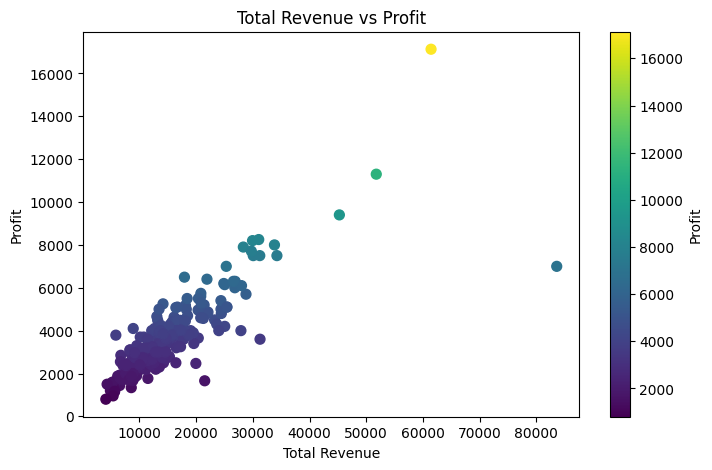

In [53]:
import matplotlib.pyplot as plt

# Scatter plot = color based on Profit value (gradient)
plt.figure(figsize=(8,5))
scatter = plt.scatter(
    df1['Total Revenue'], 
    df1['Profit'], 
    c=df1['Profit'],       # color by Profit
    cmap='viridis',        # color map (gradient from low to high)
    s=50                   # size of points
)

plt.title("Total Revenue vs Profit")
plt.xlabel("Total Revenue")
plt.ylabel("Profit")

# Add colorbar to show Profit scale
plt.colorbar(scatter, label='Profit')

plt.show()